In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Libraries imported")
print(f"   Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


Mounted at /content/drive
✅ Libraries imported
   Device: cuda
   GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 2: تحميل الصور وتنظيمها
# ════════════════════════════════════════════════════════════

# مسارات المجلدات في Google Drive
BASE = '/content/drive/MyDrive/'

folders = {
    'chanel_fake': os.path.join(BASE, '/content/drive/MyDrive/GP2 (أصيل)/Data/chanel/chanel_fake_images'),
    'chanel_real': os.path.join(BASE, '/content/drive/MyDrive/GP2 (أصيل)/Data/chanel/Chanel real images '),
    'coach_fake':  os.path.join(BASE, '/content/drive/MyDrive/GP2 (أصيل)/Data/coach/CoachFake'),
    'coach_real':  os.path.join(BASE, '/content/drive/MyDrive/GP2 (أصيل)/Data/coach/CoachReal'),
    # ── Fendi ──
    'fendi_fake':  '/content/drive/MyDrive/GP2 (أصيل)/Data/product_images/fendi/findi_fake',
    'fendi_real':  '/content/drive/MyDrive/GP2 (أصيل)/Data/product_images/fendi/FINDI_REAL',

    'lv_fake':     '/content/drive/MyDrive/GP2 (أصيل)/Data/product_images/Louis Vuitton/replica',
    'lv_real':     '/content/drive/MyDrive/GP2 (أصيل)/Data/product_images/Louis Vuitton/original',

    'prada_fake':  '/content/drive/MyDrive/GP2 (أصيل)/Data/product_images/prada/prada fake images',
    'prada_real':  '/content/drive/MyDrive/GP2 (أصيل)/Data/product_images/prada/prada real images',

    'ysl_fake':    '/content/drive/MyDrive/GP2 (أصيل)/Data/product_images/YSL/replica',
    'ysl_real':    '/content/drive/MyDrive/GP2 (أصيل)/Data/product_images/YSL/original',
}

def get_brand(key):
    mapping = {
        'chanel': 'Chanel',
        'coach':  'Coach',
        'fendi':  'Fendi',
        'lv':     'LV',
        'prada':  'Prada',
        'ysl':    'YSL',
    }
    for k, v in mapping.items():
        if key.startswith(k):
            return v
    return key

image_data = []

for key, folder_path in folders.items():
    if folder_path == '':
        print(f"⚠️ مسار فاضي: {key} — تخطي")
        continue

    brand = get_brand(key)
    is_authentic = 1 if 'real' in key else 0

    if not os.path.exists(folder_path):
        print(f"⚠️ Folder not found: {folder_path}")
        continue

    files = sorted([f for f in os.listdir(folder_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])

    for f in files:
        filepath = os.path.join(folder_path, f)
        parts = f.replace('.jpg','').replace('.jpeg','').replace('.png','').replace('.webp','').split('_')
        product_id = None
        for p in parts:
            try:
                num = int(p)
                if product_id is None:
                    product_id = num
            except:
                continue
        if product_id is None:
            product_id = f

        image_data.append({
            'filepath':     filepath,
            'filename':     f,
            'product_id':   f"{brand}_{is_authentic}_{product_id}",
            'brand':        brand,
            'is_authentic': is_authentic,
        })

    print(f"   ✅ {key}: {len(files)} images")

df_images = pd.DataFrame(image_data)

product_groups = df_images.groupby('product_id').agg({
    'filepath':     list,
    'is_authentic': 'first',
    'brand':        'first',
}).reset_index()

print(f"\n📊 Summary:")
print(f"   Total images:   {len(df_images)}")
print(f"   Total products: {len(product_groups)}")
print(f"   Fake products:  {len(product_groups[product_groups['is_authentic']==0])}")
print(f"   Real products:  {len(product_groups[product_groups['is_authentic']==1])}")
if len(product_groups) > 0:
    print(f"   Avg imgs/product: {len(df_images)/len(product_groups):.1f}")

print(f"\n📦 Per-brand breakdown:")
for brand in product_groups['brand'].unique():
    sub  = product_groups[product_groups['brand'] == brand]
    fake = len(sub[sub['is_authentic']==0])
    real = len(sub[sub['is_authentic']==1])
    print(f"   {brand:<10}: fake={fake}  real={real}")

   ✅ chanel_fake: 362 images
   ✅ chanel_real: 517 images
   ✅ coach_fake: 388 images
   ✅ coach_real: 559 images
   ✅ fendi_fake: 305 images
   ✅ fendi_real: 417 images
   ✅ lv_fake: 54 images
   ✅ lv_real: 396 images
   ✅ prada_fake: 527 images
   ✅ prada_real: 509 images
   ✅ ysl_fake: 592 images
   ✅ ysl_real: 410 images

📊 Summary:
   Total images:   5036
   Total products: 1923
   Fake products:  944
   Real products:  979
   Avg imgs/product: 2.6

📦 Per-brand breakdown:
   Chanel    : fake=94  real=94
   Coach     : fake=94  real=94
   Fendi     : fake=86  real=93
   LV        : fake=47  real=94
   Prada     : fake=527  real=509
   YSL       : fake=96  real=95


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 3: Dataset Class & Transforms
# ════════════════════════════════════════════════════════════

class BagImageDataset(Dataset):
    def __init__(self, product_ids, labels, image_paths_dict, transform=None):
        self.product_ids      = product_ids
        self.labels           = labels
        self.image_paths_dict = image_paths_dict
        self.transform        = transform

    def __len__(self):
        return len(self.product_ids)

    def __getitem__(self, idx):
        pid   = self.product_ids[idx]
        label = self.labels[idx]

        paths    = self.image_paths_dict[pid]
        img_path = paths[np.random.randint(len(paths))]

        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("✅ Dataset class & transforms defined")

✅ Dataset class & transforms defined


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 4: بناء EfficientNet-B0
# ════════════════════════════════════════════════════════════

def create_efficientnet():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.features[-3:].parameters():
        param.requires_grad = True

    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(1280, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
        nn.Sigmoid()
    )

    return model

model_test = create_efficientnet()
trainable  = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
total      = sum(p.numel() for p in model_test.parameters())
print(f"✅ EfficientNet-B0 created:")
print(f"   Total parameters:     {total:,}")
print(f"   Trainable parameters: {trainable:,} ({trainable/total*100:.1f}%)")
print(f"   Frozen parameters:    {total-trainable:,}")
del model_test

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 159MB/s]

✅ EfficientNet-B0 created:
   Total parameters:     4,335,741
   Trainable parameters: 3,483,933 (80.4%)
   Frozen parameters:    851,808


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 5: دوال التدريب والتقييم
# ════════════════════════════════════════════════════════════

def train_image_model(model, train_loader, val_loader, epochs=30, patience=10, lr=0.0001):
    criterion  = nn.BCELoss()
    optimizer  = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                   lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history          = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss    = float('inf')
    best_state       = None
    patience_counter = 0

    for epoch in range(epochs):
        # ─── Train ───
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item()
            t_correct += ((outputs >= 0.5).float() == labels).sum().item()
            t_total   += len(labels)

        # ─── Validation ───
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs   = model(images).squeeze()
                v_loss   += criterion(outputs, labels).item()
                v_correct += ((outputs >= 0.5).float() == labels).sum().item()
                v_total  += len(labels)

        avg_tl = t_loss / len(train_loader)
        avg_vl = v_loss / len(val_loader)
        t_acc  = t_correct / t_total
        v_acc  = v_correct / v_total

        history['train_loss'].append(avg_tl)
        history['val_loss'].append(avg_vl)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        scheduler.step(avg_vl)

        marker = ""
        if avg_vl < best_val_loss:
            best_val_loss    = avg_vl
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            marker           = " ✅"
        else:
            patience_counter += 1

        print(f"   Epoch {epoch+1:>2}/{epochs} | TrLoss:{avg_tl:.4f} VlLoss:{avg_vl:.4f} | TrAcc:{t_acc:.3f} VlAcc:{v_acc:.3f}{marker}")

        if patience_counter >= patience:
            print(f"   ⏹️ Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    model.to(device)
    return model, history


def evaluate_image_model(model, test_loader):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for images, lbls in test_loader:
            images  = images.to(device)
            outputs = model(images).squeeze()
            preds.extend((outputs >= 0.5).float().cpu().numpy())
            probs.extend(outputs.cpu().numpy())
            labels.extend(lbls.numpy())
    return np.array(preds), np.array(probs), np.array(labels)

print("✅ Training functions defined")

✅ Training functions defined


In [ ]:
# The corrected evaluate_image_model function
def evaluate_image_model(model, test_loader):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for images, lbls in test_loader:
            images  = images.to(device)
            outputs = model(images).squeeze()
            # Ensure the numpy array is 1D before extending to avoid TypeError
            preds.extend((outputs >= 0.5).float().cpu().numpy().flatten())
            probs.extend(outputs.cpu().numpy().flatten())
            labels.extend(lbls.numpy()) # lbls is already numpy from DataLoader batch
    return np.array(preds), np.array(probs), np.array(labels)

# ════════════════════════════════════════════════════════════
# الخلية 6: 5-Fold Cross-Validation
# ════════════════════════════════════════════════════════════

N_FOLDS    = 5
EPOCHS     = 30
BATCH_SIZE = 32   # زيادة من 16 — بيانات أكبر والـ GPU يتحمل

product_ids    = product_groups['product_id'].values
product_labels = product_groups['is_authentic'].values
product_brands = product_groups['brand'].values
stratify_col   = [f"{b}_{l}" for b, l in zip(product_brands, product_labels)]

image_paths_dict = dict(zip(product_groups['product_id'],
                             product_groups['filepath']))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

all_fold_results = []
all_true         = []
all_pred         = []
all_prob         = []
fold_histories   = []

print(f"🚀 Starting {N_FOLDS}-Fold Cross-Validation")
print(f"   Products: {len(product_ids)} | Images: {len(df_images)}")
print(f"   Model: EfficientNet-B0 | Epochs: {EPOCHS} | Batch: {BATCH_SIZE}")
print("="*70)

for fold, (train_idx, test_idx) in enumerate(skf.split(product_ids, stratify_col)):
    print(f"\n{'═'*60}")
    print(f"📌 FOLD {fold+1}/{N_FOLDS}")
    print(f"{'═'*60}")

    train_pids   = product_ids[train_idx]
    test_pids    = product_ids[test_idx]
    train_labels = product_labels[train_idx]
    test_labels  = product_labels[test_idx]

    val_size           = int(0.15 * len(train_pids))
    val_pids           = train_pids[-val_size:]
    val_labels_split   = train_labels[-val_size:]
    train_pids_split   = train_pids[:-val_size]
    train_labels_split = train_labels[:-val_size]

    print(f"   Train: {len(train_pids_split)} products")
    print(f"   Val:   {len(val_pids)} products")
    print(f"   Test:  {len(test_pids)} products")

    train_ds = BagImageDataset(train_pids_split, train_labels_split, image_paths_dict, train_transform)
    val_ds   = BagImageDataset(val_pids,         val_labels_split,   image_paths_dict, test_transform)
    test_ds  = BagImageDataset(test_pids,         test_labels,        image_paths_dict, test_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = create_efficientnet().to(device)
    model, history = train_image_model(model, train_loader, val_loader, epochs=EPOCHS)
    fold_histories.append(history)

    fold_probs_list = []
    for _ in range(5):
        _, probs, _ = evaluate_image_model(model, test_loader)
        fold_probs_list.append(probs)

    avg_probs   = np.mean(fold_probs_list, axis=0)
    final_preds = (avg_probs >= 0.5).astype(float)

    acc  = accuracy_score(test_labels,  final_preds)
    prec = precision_score(test_labels, final_preds, zero_division=0)
    rec  = recall_score(test_labels,    final_preds, zero_division=0)
    f1   = f1_score(test_labels,        final_preds, zero_division=0)
    auc  = roc_auc_score(test_labels,   avg_probs)

    all_fold_results.append({'Fold': fold+1, 'Accuracy': acc, 'Precision': prec,
                             'Recall': rec, 'F1': f1, 'AUC': auc})
    all_true.extend(test_labels)
    all_pred.extend(final_preds)
    all_prob.extend(avg_probs)

    print(f"\n   📊 Fold {fold+1} Results: Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  AUC={auc:.3f}")

    del model
    torch.cuda.empty_cache() if device.type == 'cuda' else None

all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_prob = np.array(all_prob)

print(f"\n{'='*70}")
print("✅ All folds completed!")

🚀 Starting 5-Fold Cross-Validation
   Products: 1923 | Images: 5036
   Model: EfficientNet-B0 | Epochs: 30 | Batch: 32

════════════════════════════════════════════════════════════
📌 FOLD 1/5
════════════════════════════════════════════════════════════
   Train: 1308 products
   Val:   230 products
   Test:  385 products
   Epoch  1/30 | TrLoss:0.5822 VlLoss:0.4692 | TrAcc:0.740 VlAcc:0.926 ✅
   Epoch  2/30 | TrLoss:0.3516 VlLoss:0.2827 | TrAcc:0.887 VlAcc:0.952 ✅
   Epoch  3/30 | TrLoss:0.2220 VlLoss:0.1390 | TrAcc:0.927 VlAcc:0.970 ✅
   Epoch  4/30 | TrLoss:0.1769 VlLoss:0.1090 | TrAcc:0.934 VlAcc:0.957 ✅
   Epoch  5/30 | TrLoss:0.1434 VlLoss:0.1246 | TrAcc:0.950 VlAcc:0.952
   Epoch  6/30 | TrLoss:0.1217 VlLoss:0.1032 | TrAcc:0.958 VlAcc:0.965 ✅
   Epoch  7/30 | TrLoss:0.0882 VlLoss:0.0837 | TrAcc:0.973 VlAcc:0.970 ✅
   Epoch  8/30 | TrLoss:0.0766 VlLoss:0.0768 | TrAcc:0.973 VlAcc:0.983 ✅
   Epoch  9/30 | TrLoss:0.0739 VlLoss:0.0764 | TrAcc:0.973 VlAcc:0.974 ✅
   Epoch 10/30 | TrLos

In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 7: جدول النتائج
# ════════════════════════════════════════════════════════════

fold_df = pd.DataFrame(all_fold_results)

print("\n" + "="*80)
print("📊 EXPERIMENT 2: IMAGE ONLY — RESULTS (5-Fold CV)")
print("="*80)
print(f"\n{'Fold':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'AUC-ROC':>10}")
print("─" * 60)
for _, row in fold_df.iterrows():
    print(f"{int(row['Fold']):>6} {row['Accuracy']:>10.4f} {row['Precision']:>10.4f} {row['Recall']:>10.4f} {row['F1']:>10.4f} {row['AUC']:>10.4f}")
print("─" * 60)
print(f"{'Mean':>6} {fold_df['Accuracy'].mean():>10.4f} {fold_df['Precision'].mean():>10.4f} {fold_df['Recall'].mean():>10.4f} {fold_df['F1'].mean():>10.4f} {fold_df['AUC'].mean():>10.4f}")
print(f"{'Std':>6} {fold_df['Accuracy'].std():>10.4f} {fold_df['Precision'].std():>10.4f} {fold_df['Recall'].std():>10.4f} {fold_df['F1'].std():>10.4f} {fold_df['AUC'].std():>10.4f}")
print(f"\n📊 Final: Acc={fold_df['Accuracy'].mean():.4f}±{fold_df['Accuracy'].std():.4f}  F1={fold_df['F1'].mean():.4f}±{fold_df['F1'].std():.4f}  AUC={fold_df['AUC'].mean():.4f}±{fold_df['AUC'].std():.4f}")
display(fold_df)


📊 EXPERIMENT 2: IMAGE ONLY — RESULTS (5-Fold CV)

  Fold   Accuracy  Precision     Recall   F1-Score    AUC-ROC
────────────────────────────────────────────────────────────
     1     0.9766     0.9606     0.9949     0.9774     0.9959
     2     0.9896     0.9798     1.0000     0.9898     0.9994
     3     0.9610     0.9372     0.9898     0.9628     0.9869
     4     0.9792     0.9653     0.9949     0.9799     0.9983
     5     0.9740     0.9517     1.0000     0.9752     0.9928
────────────────────────────────────────────────────────────
  Mean     0.9761     0.9589     0.9959     0.9770     0.9947
   Std     0.0103     0.0158     0.0043     0.0097     0.0050

📊 Final: Acc=0.9761±0.0103  F1=0.9770±0.0097  AUC=0.9947±0.0050


,Fold,Accuracy,Precision,Recall,F1,AUC
0,1,0.976623,0.960591,0.994898,0.977444,0.995924
1,2,0.989610,0.979798,1.000000,0.989796,0.999406
2,3,0.961039,0.937198,0.989796,0.962779,0.986934
3,4,0.979167,0.965347,0.994898,0.979899,0.998290
4,5,0.973958,0.951691,1.000000,0.975248,0.992779


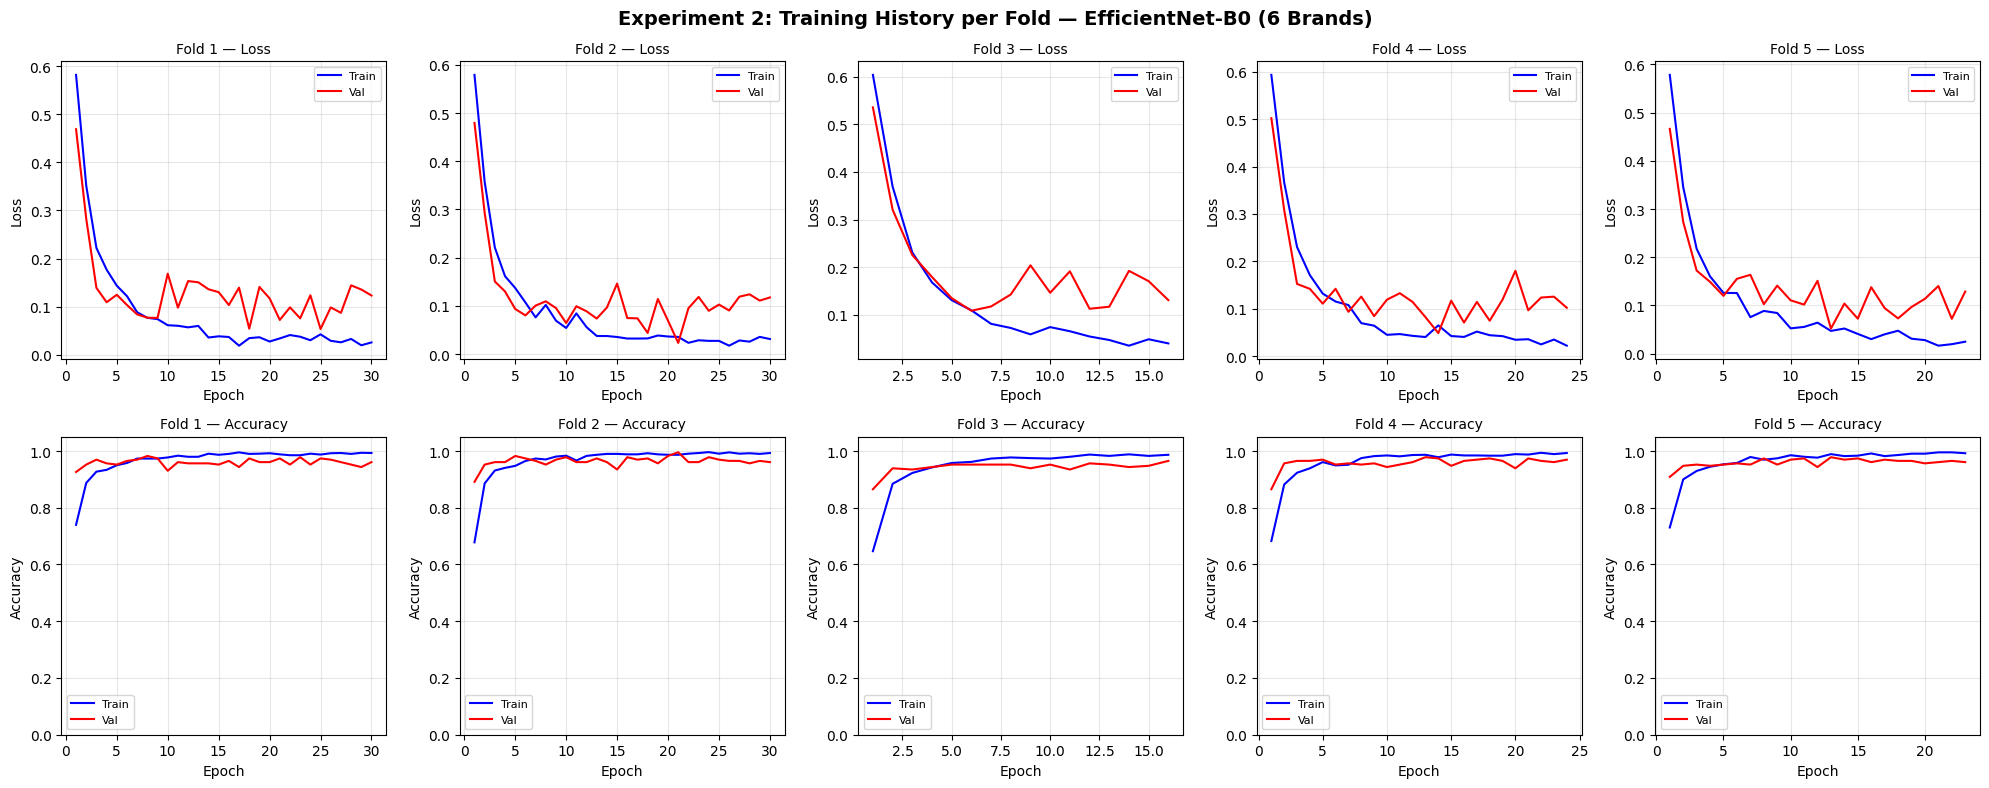

✅ Saved: exp2_training_history.png


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 8: Training History Plot
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Experiment 2: Training History per Fold — EfficientNet-B0 (6 Brands)', fontsize=14, fontweight='bold')

for fold_idx, history in enumerate(fold_histories):
    ax_loss = axes[0, fold_idx]
    ax_acc  = axes[1, fold_idx]
    epochs_range = range(1, len(history['train_loss']) + 1)

    ax_loss.plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=1.5)
    ax_loss.plot(epochs_range, history['val_loss'],   'r-', label='Val',   linewidth=1.5)
    ax_loss.set_title(f'Fold {fold_idx+1} — Loss', fontsize=10)
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=8); ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(epochs_range, history['train_acc'], 'b-', label='Train', linewidth=1.5)
    ax_acc.plot(epochs_range, history['val_acc'],   'r-', label='Val',   linewidth=1.5)
    ax_acc.set_title(f'Fold {fold_idx+1} — Accuracy', fontsize=10)
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8); ax_acc.grid(True, alpha=0.3)
    ax_acc.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('exp2_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: exp2_training_history.png")

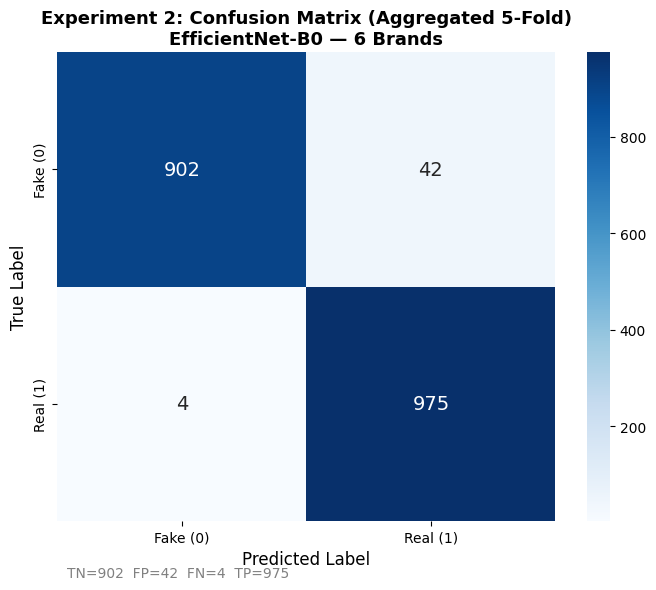

✅ Saved: exp2_confusion_matrix.png


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 9: Confusion Matrix
# ════════════════════════════════════════════════════════════

cm = confusion_matrix(all_true, all_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake (0)', 'Real (1)'],
            yticklabels=['Fake (0)', 'Real (1)'],
            annot_kws={'size': 14})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Experiment 2: Confusion Matrix (Aggregated 5-Fold)\nEfficientNet-B0 — 6 Brands', fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
ax.text(0.02, -0.12, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}', transform=ax.transAxes, fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('exp2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: exp2_confusion_matrix.png")

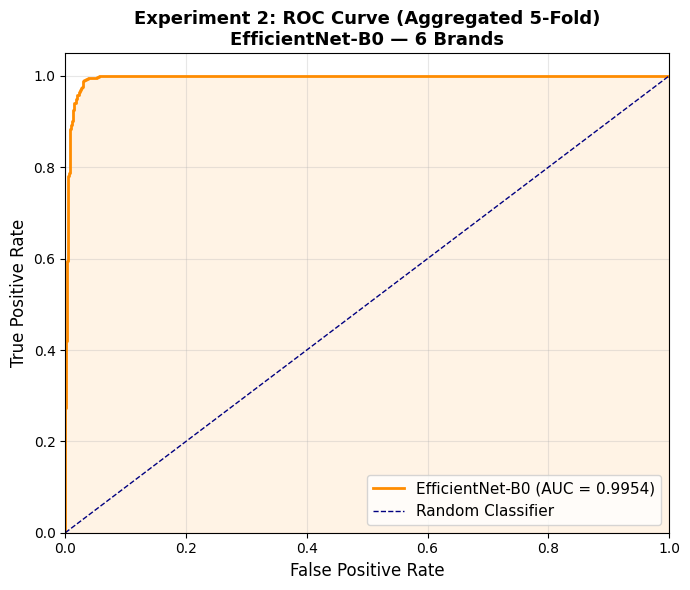

✅ Saved: exp2_roc_curve.png


In [ ]:
# ════════════════════════════════════════════════════════════
# الخلية 10: ROC Curve
# ════════════════════════════════════════════════════════════

fpr, tpr, _ = roc_curve(all_true, all_prob)
auc_score   = roc_auc_score(all_true, all_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'EfficientNet-B0 (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Experiment 2: ROC Curve (Aggregated 5-Fold)\nEfficientNet-B0 — 6 Brands', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp2_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: exp2_roc_curve.png")